In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    SELECT uid,
        timestamp,
        numTrials
        
    FROM checker
    WHERE uid LIKE 'user_%'
        AND status = 'ready'
        AND labname = 'project1'
"""
df = pd.read_sql(query, connect, parse_dates=['timestamp'])

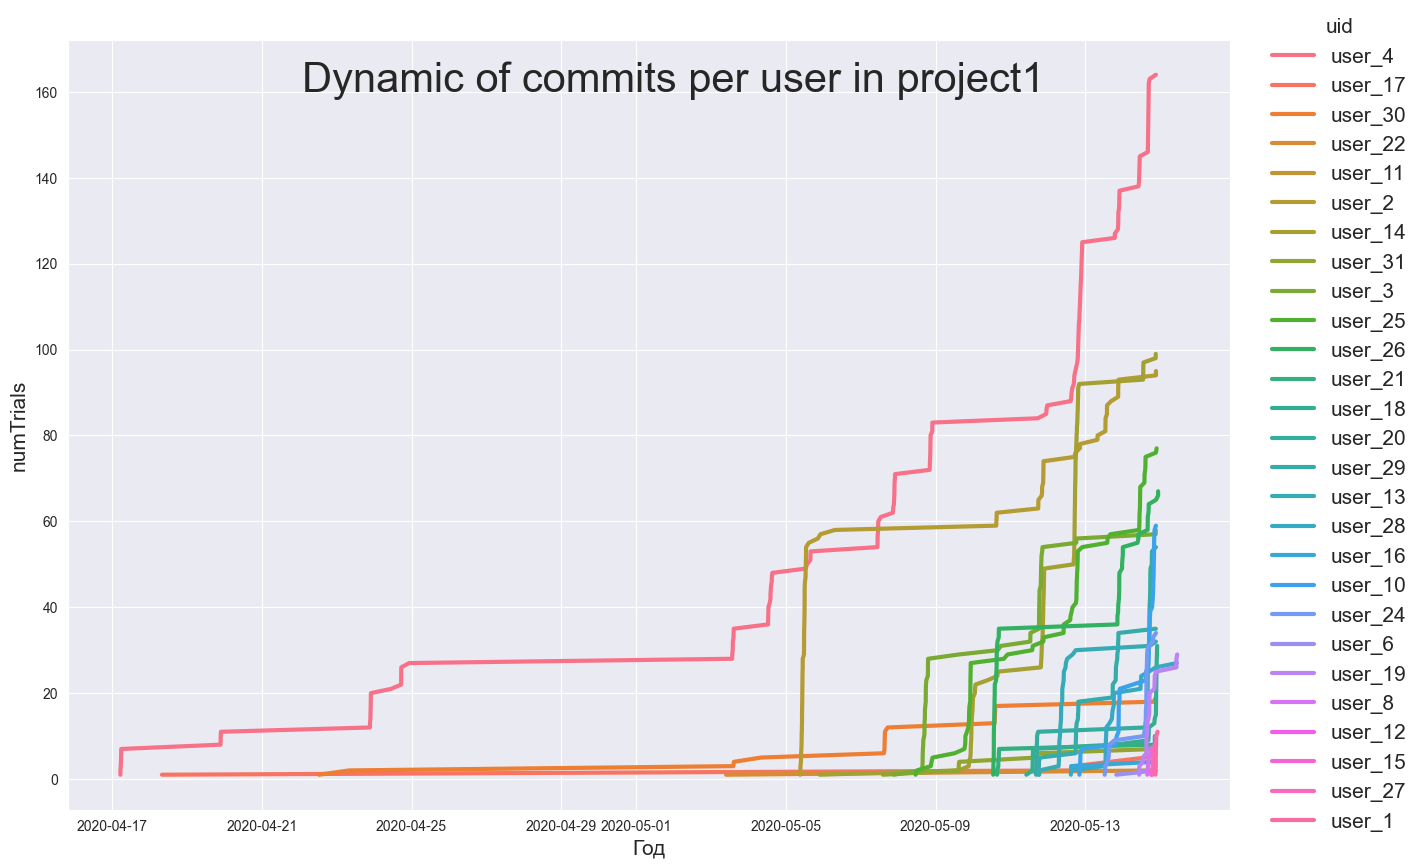

In [4]:
plt.figure(figsize=(15,10))
sns.set_style('darkgrid')
ax =  sns.lineplot(
    data=df,
    x='timestamp', 
    y='numTrials',
    hue='uid', 
    palette="husl",
    linewidth=3
)

ax.text(
    x=pd.to_datetime('2020-05-02'),
    y=160,
    s="Dynamic of commits per user in project1",
    fontsize=30,
    ha="center", 

) 

ax.set_xlabel("Год", fontsize=15)
ax.set_ylabel("numTrials", fontsize=15)

plt.legend(
    title="uid",
    title_fontsize=15,
    fontsize=15,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5), 
    frameon=False            
)
plt.show()

In [5]:
connect.close()

### Какой пользователь лидировал по количеству коммитов почти всегда?
### Ответ: user_4
### Какой пользователь был лидером только короткий период времени?
### Ответ: user_2